# SWaT ICS — Full ML Pipeline
### Secure Water Treatment Intrusion Detection · 9 Attack Classes · 4 Runs Merged

**Pipeline:**  Load → Preprocess → Feature Engineering → NaN Audit → Scale → SMOTE  
→ Random Forest · XGBoost · SVM · MLP · BiLSTM → Evaluate → Save `.joblib`

---
| Section | Content |
|---------|---------|
| 0 | Imports & config |
| 1 | Data loading & validation |
| 2 | Preprocessing (dead cols, leakage, normalise tanks) |
| 3 | Temporal feature engineering |
| 4 | **NaN audit & guaranteed clean matrix** |
| 5 | Train/test split + scaling |
| 6 | Class balancing (SMOTE) |
| 7 | Classical ML — binary |
| 8 | Classical ML — multi-class |
| 9 | MLP neural network |
| 10 | BiLSTM + Attention |
| 11 | Evaluation & comparison |
| 12 | Save all models |
| 13 | Inference demo |


## 0 · Imports & Configuration

In [1]:
# ── Install (run once) ────────────────────────────────────────────────────────
# !pip install scikit-learn xgboost imbalanced-learn joblib torch matplotlib seaborn pandas numpy

import os, warnings, json as _json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, accuracy_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance
import joblib
import xgboost as xgb
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device : {DEVICE}")
print(f"XGBoost version: {xgb.__version__}")

MODELS_DIR = Path("saved_models"); MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR  = Path("plots");        PLOTS_DIR.mkdir(exist_ok=True)

# ── Attack registry ───────────────────────────────────────────────────────────
ATTACK_NAMES = {
    0: "Normal Operation",
    1: "Tank Overflow Attack",
    2: "Chemical Depletion Attack",
    3: "Membrane Damage Attack",
    4: "pH Manipulation Attack",
    5: "Slow Ramp Attack",
    6: "Reconnaissance Scan",
    7: "Denial of Service",
    8: "Replay Attack",
    9: "Valve Manipulation Attack",
}
NUM_CLASSES = 10
# Original IDs in merged CSV → sequential 0-9
ID_REMAP = {0:0, 8:1, 9:2, 10:3, 11:4, 12:5, 13:6, 14:7, 15:8, 16:9}


PyTorch device : cpu
XGBoost version: 3.2.0


## 1 · Data Loading & Validation

In [2]:
DATA_PATH = "final.csv"   # adjust path if needed

df_raw = pd.read_csv(DATA_PATH)
df_raw['ATTACK_ID']   = df_raw['ATTACK_ID'].map(ID_REMAP)
df_raw['ATTACK_NAME'] = df_raw['ATTACK_ID'].map(ATTACK_NAMES)
df_raw['ts']          = pd.to_datetime(df_raw['Timestamp'])
df_raw = df_raw.sort_values(['run_id', 'elapsed_seconds']).reset_index(drop=True)

print(f"Shape          : {df_raw.shape}")
print(f"Missing values : {df_raw.isnull().sum().sum()}")
print(f"Duplicate rows : {df_raw.duplicated().sum()}")
print(f"Runs           : {sorted(df_raw['run_id'].unique())}")
print(f"\nAttack distribution:")
dist = (df_raw.groupby(['ATTACK_ID','ATTACK_NAME'])
        .size().reset_index(name='rows'))
dist['%'] = (dist['rows']/len(df_raw)*100).round(2)
print(dist.to_string(index=False))


Shape          : (118634, 76)
Missing values : 0
Duplicate rows : 0
Runs           : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Attack distribution:
 ATTACK_ID               ATTACK_NAME  rows     %
         0          Normal Operation 83386 70.29
         1      Tank Overflow Attack  4790  4.04
         2 Chemical Depletion Attack  1594  1.34
         3    Membrane Damage Attack  2475  2.09
         4    pH Manipulation Attack  3876  3.27
         5          Slow Ramp Attack  6299  5.31
         6       Reconnaissance Scan  5196  4.38
         7         Denial of Service   980  0.83
         8             Replay Attack  3861  3.25
         9 Valve Manipulation Attack  6177  5.21


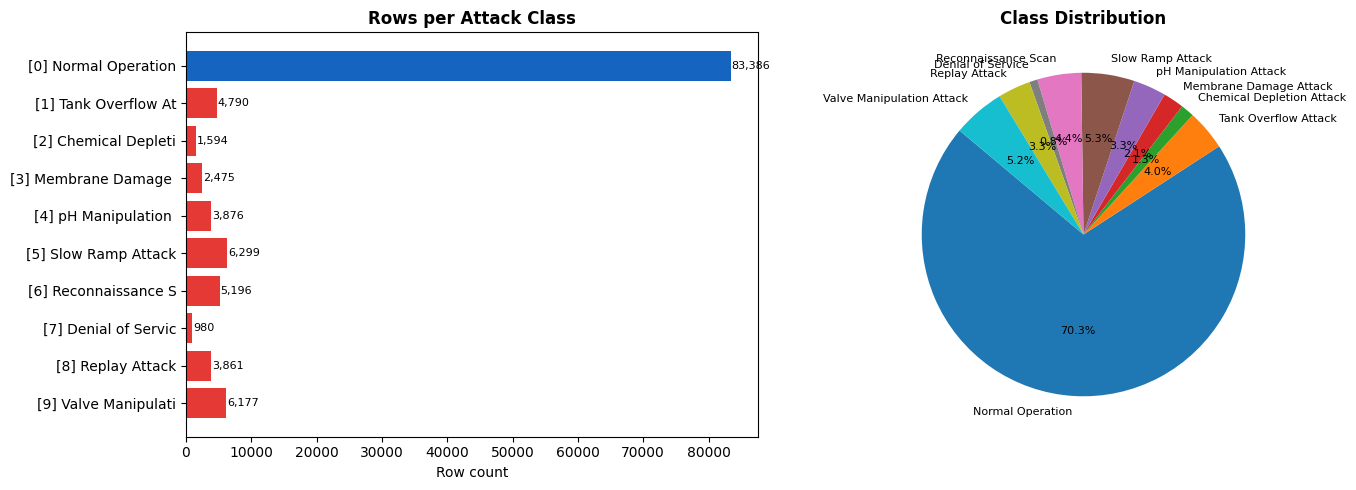

In [3]:
# ── Class distribution plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df_raw.groupby('ATTACK_ID').size()
short  = [f"[{i}] {ATTACK_NAMES[i][:16]}" for i in counts.index]
colors = ['#1565C0' if i == 0 else '#E53935' for i in counts.index]

axes[0].barh(short[::-1], counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Row count")
axes[0].set_title("Rows per Attack Class", fontweight='bold')
for i, v in enumerate(counts.values[::-1]):
    axes[0].text(v + 100, i, f"{v:,}", va='center', fontsize=8)

axes[1].pie(counts.values, labels=[ATTACK_NAMES[i] for i in counts.index],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
axes[1].set_title("Class Distribution", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()


## 2 · Preprocessing

### 2.1  Drop dead / near-constant / leakage columns

In [4]:
# Columns confirmed dead/near-constant across all 4 runs (from validation report)
# IMPORTANT: Energy counters & runtime counters removed — they encode TIME not attacks
DEAD_COLS = [
    # Stage 5 RO — near-constant (98-99% flat)
    'DPIT_301','FIT_301','UF_Last_Backwash','Turbidity_UF',
    'AIT_501','AIT_502','AIT_503','AIT_504',
    'FIT_501','FIT_502','FIT_503','FIT_504',
    'PIT_501','PIT_502','PIT_503',
    'RO_Runtime','RO_Fouling_Factor','RO_Last_Cleaning',
    'TDS_Feed','TDS_Permeate','FIT_601',
    # Monotone counters — encode time position, NOT attack behaviour (data leakage!)
    'Energy_P101','Energy_P301','Energy_P501','Energy_Total',
    'UF_Runtime','UF_Last_Backwash',
    # Dead booleans — always same state
    'P_203','MV_303','MV_304','P_301','UF_Backwash_Active',
    'P_403','P_501','RO_Cleaning_Active','P_601','P_602','P_603',
    'High_Fouling_Alarm',
    # Redundant — identical to High_Level_Alarm
    'System_Run',
    # Near-zero correlation
    'UV_401',
    # Metadata — not model inputs
    'Timestamp','ATTACK_NAME','MITRE_ID','ts',
]
DEAD_COLS = [c for c in DEAD_COLS if c in df_raw.columns]
df = df_raw.drop(columns=DEAD_COLS).copy()
print(f"Dropped {len(DEAD_COLS)} columns: {df_raw.shape[1]} -> {df.shape[1]}")
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")


Dropped 45 columns: 76 -> 32
Remaining columns (32): ['FIT_101', 'LIT_101', 'MV_101', 'P_101', 'P_102', 'AIT_201', 'AIT_202', 'AIT_203', 'Chlorine_Residual', 'FIT_201', 'MV_201', 'P_205', 'P_206', 'Acid_Tank_Level', 'Chlorine_Tank_Level', 'Coagulant_Tank_Level', 'Bisulfate_Tank_Level', 'LIT_301', 'MV_301', 'MV_302', 'UF_Fouling_Factor', 'AIT_401', 'AIT_402', 'FIT_401', 'LIT_401', 'P_401', 'Turbidity_Raw', 'Chemical_Low_Alarm', 'High_Level_Alarm', 'ATTACK_ID', 'elapsed_seconds', 'run_id']


### 2.2  Remove boundary label leakage (±4 s around attack transitions)

In [5]:
def remove_leakage(df, time_col='elapsed_seconds', label_col='ATTACK_ID',
                   run_col='run_id', window_s=4.0):
    parts, total_removed = [], 0
    for rid, grp in df.groupby(run_col):
        grp = grp.sort_values(time_col).reset_index(drop=True)
        t_changes = grp[label_col].diff().abs() > 0
        t_times   = grp.loc[t_changes, time_col].values
        mask = pd.Series(False, index=grp.index)
        for t in t_times:
            mask |= (grp[time_col] - t).abs() <= window_s
        total_removed += mask.sum()
        parts.append(grp[~mask])
    out = pd.concat(parts, ignore_index=True)
    print(f"Removed {total_removed:,} leakage rows  "
          f"({total_removed/len(df)*100:.2f}%)  ->  {len(out):,} rows remain")
    return out

df = remove_leakage(df, window_s=4.0)


Removed 800 leakage rows  (0.67%)  ->  117,834 rows remain


### 2.3  Per-run tank normalisation (fixes 25-unit Acid_Tank cross-run drift)

In [6]:
TANK_COLS = ['Acid_Tank_Level','Chlorine_Tank_Level',
             'Coagulant_Tank_Level','Bisulfate_Tank_Level']
TANK_COLS = [c for c in TANK_COLS if c in df.columns]

for col in TANK_COLS:
    # starting level = first normal-state reading in each run
    run_start = (df[df['ATTACK_ID'] == 0]
                 .groupby('run_id')[col].first()
                 .rename('_start'))
    df = df.join(run_start, on='run_id')
    df[f'{col}_pct'] = ((df['_start'] - df[col]) / df['_start'].clip(lower=1)
                        ).clip(0, 1)
    df.drop(columns=['_start'], inplace=True)

pct_cols = [c for c in df.columns if c.endswith('_pct')]
print("Added per-run normalised depletion columns:", pct_cols)
print(df[pct_cols].describe().round(4))


Added per-run normalised depletion columns: ['Acid_Tank_Level_pct', 'Chlorine_Tank_Level_pct', 'Coagulant_Tank_Level_pct', 'Bisulfate_Tank_Level_pct']
       Acid_Tank_Level_pct  Chlorine_Tank_Level_pct  Coagulant_Tank_Level_pct  \
count          117834.0000              117834.0000               117834.0000   
mean                0.0795                   0.1721                    0.1527   
std                 0.1646                   0.2296                    0.2201   
min                 0.0000                   0.0000                    0.0000   
25%                 0.0000                   0.0000                    0.0000   
50%                 0.0000                   0.0000                    0.0000   
75%                 0.0000                   0.3448                    0.2812   
max                 0.9733                   0.9855                    0.9655   

       Bisulfate_Tank_Level_pct  
count               117834.0000  
mean                     0.0080  
std              

### 2.4  Convert booleans to int

In [7]:
bool_cols = [c for c in df.columns if df[c].dtype == bool]
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(np.int8)
    print(f"Converted {len(bool_cols)} bool -> int8: {bool_cols}")
else:
    # Handle object columns that look boolean
    for c in df.select_dtypes(include='object').columns:
        if c in ('ATTACK_ID','run_id','elapsed_seconds'): continue
        uniq = set(df[c].dropna().unique())
        if uniq <= {'True','False','true','false','1','0',True,False,1,0}:
            df[c] = df[c].map(
                {'True':1,'False':0,'true':1,'false':0,'1':1,'0':0,1:1,0:0,
                 True:1,False:0}).astype(np.int8)
    print("Bool conversion done")
print(f"dtypes: {df.dtypes.value_counts().to_dict()}")


Converted 11 bool -> int8: ['MV_101', 'P_101', 'P_102', 'MV_201', 'P_205', 'P_206', 'MV_301', 'MV_302', 'P_401', 'Chemical_Low_Alarm', 'High_Level_Alarm']
dtypes: {dtype('float64'): 13, dtype('int64'): 12, dtype('int8'): 11}


## 3 · Temporal Feature Engineering

In [8]:
WINDOW_SIZES      = [10, 25, 50]   # samples → 2s, 5s, 10s at 5 Hz
TEMPORAL_SENSORS  = [c for c in
    ['LIT_101','LIT_301','LIT_401','AIT_202','FIT_101','FIT_401',
     'Acid_Tank_Level','Chlorine_Residual']
    if c in df.columns]
print("Building temporal features for:", TEMPORAL_SENSORS)

def add_temporal_features(df, sensors, windows, run_col='run_id',
                           time_col='elapsed_seconds'):
    """
    Adds per-run (no cross-run leakage):
      - 1st derivative  : d_{s}_dt
      - Rolling mean    : {s}_rmean{w}
      - Rolling std     : {s}_rstd{w}
      - CUSUM           : {s}_cusum
    All NaN values are filled within each run before concatenation.
    """
    parts = []
    for rid, grp in df.groupby(run_col):
        grp = grp.sort_values(time_col).copy().reset_index(drop=True)
        dt  = grp[time_col].diff().fillna(0.2).clip(lower=0.01)

        for s in sensors:
            if s not in grp.columns:
                continue
            col_vals = grp[s].astype(float)

            # ── 1st derivative (units/second) ─────────────────────────────
            deriv = col_vals.diff() / dt
            # Fill leading NaN with 0 (no change at start)
            grp[f'd_{s}_dt'] = deriv.fillna(0)

            # ── Rolling statistics ─────────────────────────────────────────
            for w in windows:
                roll = col_vals.rolling(w, min_periods=1)   # min_periods=1 → never NaN
                grp[f'{s}_rmean{w}'] = roll.mean()
                grp[f'{s}_rstd{w}']  = roll.std().fillna(0)  # std NaN on single sample → 0

            # ── CUSUM ──────────────────────────────────────────────────────
            # Baseline = expanding mean of first 50 samples, then rolling
            baseline = col_vals.expanding(min_periods=1).mean()
            deviation = col_vals - baseline
            cusum = deviation.cumsum()
            # Reset to 0 at start of run (no inter-run drift)
            grp[f'{s}_cusum'] = cusum - cusum.iloc[0]

        # ── Final NaN sweep for this run ───────────────────────────────────
        new_cols = ([f'd_{s}_dt'] +
                    [f'{s}_rmean{w}' for w in windows] +
                    [f'{s}_rstd{w}'  for w in windows] +
                    [f'{s}_cusum']
                    for s in sensors if s in grp.columns)
        for col_group in new_cols:
            for c in col_group:
                if c in grp.columns and grp[c].isna().any():
                    grp[c] = grp[c].ffill().bfill().fillna(0)

        parts.append(grp)

    return pd.concat(parts, ignore_index=True)

print("Computing... (may take ~30s)")
df = add_temporal_features(df, TEMPORAL_SENSORS, WINDOW_SIZES)

new_feats = [c for c in df.columns
             if any(x in c for x in ['_rmean','_rstd','d_','_cusum'])]
print(f"Added {len(new_feats)} temporal features")
print(f"Total columns: {df.shape[1]}  |  Total rows: {df.shape[0]:,}")


Building temporal features for: ['LIT_101', 'LIT_301', 'LIT_401', 'AIT_202', 'FIT_101', 'FIT_401', 'Acid_Tank_Level', 'Chlorine_Residual']
Computing... (may take ~30s)
Added 67 temporal features
Total columns: 100  |  Total rows: 117,834


## 4 · NaN Audit — Guaranteed Clean Matrix

In [9]:
# ── Define feature columns ────────────────────────────────────────────────────
NON_FEATURE = {'ATTACK_ID', 'run_id', 'elapsed_seconds'}
FEATURE_COLS = [c for c in df.columns
                if c not in NON_FEATURE
                and df[c].dtype in (np.float64, np.float32, np.int64,
                                    np.int32, np.int16, np.int8, float, int)]

print(f"Feature columns selected: {len(FEATURE_COLS)}")

# ── Build raw feature matrix ──────────────────────────────────────────────────
X_raw = df[FEATURE_COLS].copy()

# ── Step 1: report any NaN per column ────────────────────────────────────────
nan_per_col = X_raw.isna().sum()
nan_cols = nan_per_col[nan_per_col > 0]
if len(nan_cols):
    print(f"\nNaN found in {len(nan_cols)} columns BEFORE fix:")
    print(nan_cols)
else:
    print("\nNo NaN found — all clear before fix")

# ── Step 2: fill forward within run, then backward, then 0 ───────────────────
X_raw = X_raw.copy()
# Re-attach run_id for group-wise fill
X_raw['_run'] = df['run_id'].values

X_filled = (X_raw.groupby('_run', group_keys=False)
            .apply(lambda g: g.ffill().bfill())
            .fillna(0))
X_filled = X_filled.drop(columns=['_run'])

# ── Step 3: replace any remaining inf with column median ─────────────────────
inf_mask = np.isinf(X_filled.values)
if inf_mask.any():
    print(f"Found {inf_mask.sum()} inf values — replacing with column median")
    for i, c in enumerate(X_filled.columns):
        col_inf = np.isinf(X_filled[c].values)
        if col_inf.any():
            med = np.nanmedian(X_filled[c].values[~col_inf])
            X_filled.loc[col_inf, c] = med

# ── Step 4: final verification ────────────────────────────────────────────────
nan_after = X_filled.isna().sum().sum()
inf_after = np.isinf(X_filled.values).sum()
print(f"\nAFTER fill — NaN: {nan_after}  |  Inf: {inf_after}")
assert nan_after == 0 and inf_after == 0, "Still have NaN/Inf — check above!"
print("AUDIT PASSED: feature matrix is clean")

X = X_filled.values.astype(np.float32)
y = df['ATTACK_ID'].values.astype(np.int64)
y_binary = (y > 0).astype(np.int64)
print(f"\nX shape: {X.shape}   dtype: {X.dtype}")
print(f"y unique: {np.unique(y)}   binary: Normal={np.sum(y==0):,}  Attack={np.sum(y>0):,}")


Feature columns selected: 97

No NaN found — all clear before fix

AFTER fill — NaN: 0  |  Inf: 0
AUDIT PASSED: feature matrix is clean

X shape: (117834, 97)   dtype: float32
y unique: [0 1 2 3 4 5 6 7 8 9]   binary: Normal=82,986  Attack=34,848


## 5 · Train / Test Split & Scaling

In [10]:
X_train, X_test, y_train, y_test, y_bin_train, y_bin_test = train_test_split(
    X, y, y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

# ── RobustScaler ──────────────────────────────────────────────────────────────
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)

# ── Verify no NaN/Inf after scaling ──────────────────────────────────────────
for name, arr in [("train", X_train_sc), ("test", X_test_sc)]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    status = "OK" if n_nan == 0 and n_inf == 0 else "PROBLEM"
    print(f"[{status}] {name}: NaN={n_nan}  Inf={n_inf}  range=[{lo:.4f}, {hi:.4f}]")

joblib.dump(scaler, MODELS_DIR / "scaler.joblib")
print("\nScaler saved: saved_models/scaler.joblib")


Train: 94,267  |  Test: 23,567
[OK] train: NaN=0  Inf=0  range=[-270.0000, 799.0000]
[OK] test: NaN=0  Inf=0  range=[-270.0000, 799.0000]

Scaler saved: saved_models/scaler.joblib


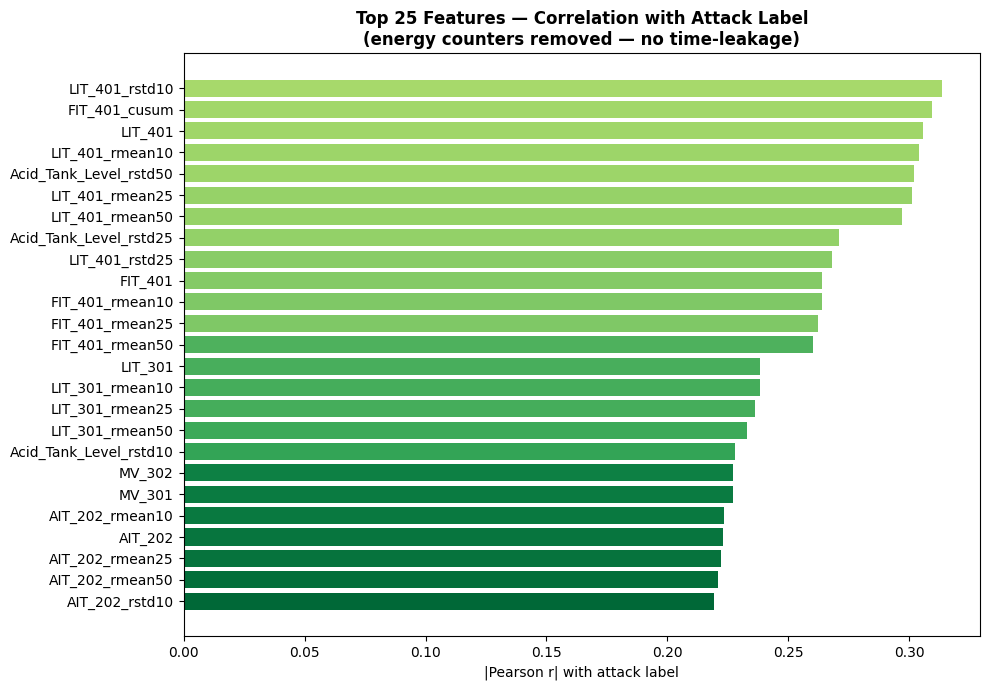

Top 15 features:
  LIT_401_rstd10                           0.3135
  FIT_401_cusum                            0.3092
  LIT_401                                  0.3055
  LIT_401_rmean10                          0.3040
  Acid_Tank_Level_rstd50                   0.3021
  LIT_401_rmean25                          0.3012
  LIT_401_rmean50                          0.2969
  Acid_Tank_Level_rstd25                   0.2708
  LIT_401_rstd25                           0.2682
  FIT_401                                  0.2640
  FIT_401_rmean10                          0.2637
  FIT_401_rmean25                          0.2624
  FIT_401_rmean50                          0.2601
  LIT_301                                  0.2385
  LIT_301_rmean10                          0.2382


In [11]:
# ── Correlation heatmap (top 25 features — now without counter leakage) ───────
corr_series = (pd.DataFrame(X_train_sc, columns=FEATURE_COLS)
               .corrwith(pd.Series(y_bin_train.astype(float)))
               .abs()
               .sort_values(ascending=False))

top25 = corr_series.head(25)
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(top25.values / top25.values.max())
ax.barh(top25.index[::-1], top25.values[::-1], color=colors)
ax.set_xlabel("|Pearson r| with attack label")
ax.set_title("Top 25 Features — Correlation with Attack Label\n"
             "(energy counters removed — no time-leakage)", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_feature_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 features:")
for f, v in top25.head(15).items():
    print(f"  {f:<40s} {v:.4f}")


## 6 · Class Balancing — SMOTE + Class Weights

In [12]:
print("Class distribution BEFORE SMOTE:")
for cls, cnt in sorted(Counter(y_train).items()):
    print(f"  [{cls}] {ATTACK_NAMES[cls]:<35s} {cnt:>6,}")

# Oversample only the most underrepresented classes
# k_neighbors=3 is safe even for smallest class (DoS ~784 samples)
smote = SMOTE(
    random_state=42,
    k_neighbors=3,
    sampling_strategy={
        2: 4000,   # Chemical Depletion  (~1.3k → 4k)
        3: 4000,   # Membrane Damage     (~2k   → 4k)
        7: 4000,   # Denial of Service   (~784  → 4k)
    }
)
X_bal, y_bal = smote.fit_resample(X_train_sc, y_train)
y_bin_bal    = (y_bal > 0).astype(np.int64)

print("\nClass distribution AFTER SMOTE:")
for cls, cnt in sorted(Counter(y_bal).items()):
    print(f"  [{cls}] {ATTACK_NAMES[cls]:<35s} {cnt:>6,}")
print(f"\nTotal training samples: {len(X_bal):,}")

# ── Class weights ─────────────────────────────────────────────────────────────
classes_mc  = np.unique(y_bal)
weights_mc  = compute_class_weight('balanced', classes=classes_mc, y=y_bal)
cw_mc       = dict(zip(classes_mc.tolist(), weights_mc.tolist()))

classes_bin = np.array([0, 1])
weights_bin = compute_class_weight('balanced', classes=classes_bin, y=y_bin_bal)
cw_bin      = {0: float(weights_bin[0]), 1: float(weights_bin[1])}

print("\nClass weights (multi-class):")
for c, w in cw_mc.items():
    print(f"  [{c}] {ATTACK_NAMES[c]:<35s} {w:.4f}")
print(f"\nBinary weights: Normal={cw_bin[0]:.3f}  Attack={cw_bin[1]:.3f}")


Class distribution BEFORE SMOTE:
  [0] Normal Operation                    66,389
  [1] Tank Overflow Attack                 3,800
  [2] Chemical Depletion Attack            1,259
  [3] Membrane Damage Attack               1,964
  [4] pH Manipulation Attack               3,069
  [5] Slow Ramp Attack                     4,991
  [6] Reconnaissance Scan                  4,093
  [7] Denial of Service                      768
  [8] Replay Attack                        3,041
  [9] Valve Manipulation Attack            4,893

Class distribution AFTER SMOTE:
  [0] Normal Operation                    66,389
  [1] Tank Overflow Attack                 3,800
  [2] Chemical Depletion Attack            4,000
  [3] Membrane Damage Attack               4,000
  [4] pH Manipulation Attack               3,069
  [5] Slow Ramp Attack                     4,991
  [6] Reconnaissance Scan                  4,093
  [7] Denial of Service                    4,000
  [8] Replay Attack                        3,041
  [

## 7 · Classical ML — Binary Detection

In [13]:
def fit_evaluate(model, Xtr, ytr, Xte, yte, name, label_names=None, save_as=None):
    print(f"\nFitting {name}...")
    model.fit(Xtr, ytr)
    ypred = model.predict(Xte)
    acc = accuracy_score(yte, ypred)
    f1  = f1_score(yte, ypred, average='macro', zero_division=0)
    print(f"  Accuracy : {acc:.4f}   Macro F1 : {f1:.4f}")
    if label_names:
        print(classification_report(yte, ypred, target_names=label_names, digits=4))
    if save_as:
        joblib.dump(model, MODELS_DIR / save_as)
        print(f"  Saved: {save_as}")
    return {'model': model, 'name': name, 'acc': acc, 'f1': f1,
            'y_pred': ypred, 'y_true': yte}

BIN_LABELS = ["Normal", "Attack"]


In [14]:
# ── 7.1 Random Forest Binary ─────────────────────────────────────────────────
rf_bin = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2, class_weight=cw_bin,
    n_jobs=-1, random_state=42)
r_rf_bin = fit_evaluate(rf_bin, X_bal, y_bin_bal, X_test_sc, y_bin_test,
                         "Random Forest (Binary)", BIN_LABELS, "rf_binary.joblib")



Fitting Random Forest (Binary)...
  Accuracy : 0.9987   Macro F1 : 0.9985
              precision    recall  f1-score   support

      Normal     0.9987    0.9995    0.9991     16597
      Attack     0.9987    0.9970    0.9978      6970

    accuracy                         0.9987     23567
   macro avg     0.9987    0.9982    0.9985     23567
weighted avg     0.9987    0.9987    0.9987     23567

  Saved: rf_binary.joblib


In [15]:
# ── 7.2 XGBoost Binary ───────────────────────────────────────────────────────
scale_pos = float(np.sum(y_bin_bal == 0) / np.sum(y_bin_bal == 1))
xgb_bin = xgb.XGBClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss', random_state=42, n_jobs=-1)
r_xgb_bin = fit_evaluate(xgb_bin, X_bal, y_bin_bal, X_test_sc, y_bin_test,
                          "XGBoost (Binary)", BIN_LABELS, "xgb_binary.joblib")



Fitting XGBoost (Binary)...
  Accuracy : 0.9994   Macro F1 : 0.9993
              precision    recall  f1-score   support

      Normal     0.9998    0.9994    0.9996     16597
      Attack     0.9986    0.9994    0.9990      6970

    accuracy                         0.9994     23567
   macro avg     0.9992    0.9994    0.9993     23567
weighted avg     0.9994    0.9994    0.9994     23567

  Saved: xgb_binary.joblib


In [ ]:
# ── 7.3 SVM Binary (subsample — SVM is O(n²)) ────────────────────────────────
SVM_N = 30_000
idx = np.random.RandomState(42).choice(len(X_bal), min(SVM_N, len(X_bal)), replace=False)
svm_bin = SVC(kernel='rbf', C=10, gamma='scale', class_weight=cw_bin,
              probability=True, random_state=42)
r_svm_bin = fit_evaluate(svm_bin, X_bal[idx], y_bin_bal[idx], X_test_sc, y_bin_test,
                          "SVM RBF (Binary)", BIN_LABELS, "svm_binary.joblib")



Fitting SVM RBF (Binary)...


In [ ]:
# ── Binary ROC curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (mdl, name, col) in zip(axes, [
    (rf_bin,  "Random Forest", '#1565C0'),
    (xgb_bin, "XGBoost",       '#2E7D32'),
    (svm_bin, "SVM RBF",       '#E65100'),
]):
    proba = mdl.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_bin_test, proba)
    auc = roc_auc_score(y_bin_test, proba)
    ax.plot(fpr, tpr, lw=2, color=col, label=f"AUC = {auc:.4f}")
    ax.plot([0,1],[0,1], '--', color='grey', lw=1)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle("ROC Curves — Binary Detection", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_roc_binary.png", dpi=150, bbox_inches='tight')
plt.show()


## 8 · Classical ML — Multi-Class (10 Classes)

In [ ]:
MC_LABELS = [ATTACK_NAMES[i] for i in range(NUM_CLASSES)]

# ── 8.1 Random Forest Multi-class ────────────────────────────────────────────
rf_mc = RandomForestClassifier(
    n_estimators=400, min_samples_leaf=1, class_weight=cw_mc,
    n_jobs=-1, random_state=42)
r_rf_mc = fit_evaluate(rf_mc, X_bal, y_bal, X_test_sc, y_test,
                        "Random Forest (Multi-class)", MC_LABELS, "rf_multiclass.joblib")


In [ ]:
# ── 8.2 XGBoost Multi-class ───────────────────────────────────────────────────
xgb_mc = xgb.XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=NUM_CLASSES,
    eval_metric='mlogloss', random_state=42, n_jobs=-1)
r_xgb_mc = fit_evaluate(xgb_mc, X_bal, y_bal, X_test_sc, y_test,
                         "XGBoost (Multi-class)", MC_LABELS, "xgb_multiclass.joblib")


In [ ]:
# ── 8.3 Confusion matrices side-by-side ──────────────────────────────────────
short = [f"[{i}] {ATTACK_NAMES[i][:14]}" for i in range(NUM_CLASSES)]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, res, title in zip(axes,
    [r_rf_mc, r_xgb_mc],
    ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(res['y_true'], res['y_pred'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short, yticklabels=short,
                ax=ax, linewidths=0.4, annot_kws={'size': 7})
    ax.set_title(f"{title}  (Macro F1={res['f1']:.4f})", fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_confusion_matrix_mc.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 8.4 Feature importance from Random Forest ─────────────────────────────────
imp = pd.Series(rf_mc.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top30 = imp.head(30)

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(top30.index[::-1], top30.values[::-1],
        color=plt.cm.viridis(np.linspace(0.1, 0.9, 30)))
ax.set_xlabel("Gini Importance")
ax.set_title("Top 30 Feature Importances — Random Forest Multi-class\n"
             "(energy/time counters removed)", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_feature_importance_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Top 15:")
for f, v in top30.head(15).items():
    print(f"  {f:<45s} {v:.5f}")


## 9 · MLP Neural Network (Tabular)

In [ ]:
class SWaTMLP(nn.Module):
    """Fully-connected MLP with BatchNorm + Dropout for ICS tabular data."""
    def __init__(self, input_dim, hidden_dims, num_classes, dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

INPUT_DIM = X_bal.shape[1]
mlp_mc = SWaTMLP(INPUT_DIM, [512, 256, 128, 64], NUM_CLASSES, dropout=0.3).to(DEVICE)
mlp_bin = SWaTMLP(INPUT_DIM, [256, 128, 64],     2,           dropout=0.25).to(DEVICE)
print(mlp_mc)
print(f"\nMulti-class params : {sum(p.numel() for p in mlp_mc.parameters()):,}")
print(f"Binary params      : {sum(p.numel() for p in mlp_bin.parameters()):,}")


In [ ]:
def make_loaders(Xtr, ytr, Xte, yte, batch=1024):
    tr = DataLoader(TensorDataset(torch.FloatTensor(Xtr), torch.LongTensor(ytr)),
                    batch_size=batch, shuffle=True,  num_workers=0)
    te = DataLoader(TensorDataset(torch.FloatTensor(Xte), torch.LongTensor(yte)),
                    batch_size=batch, shuffle=False, num_workers=0)
    return tr, te

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, n = 0., 0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item() * len(yb)
        correct  += (out.argmax(1) == yb).sum().item()
        n        += len(yb)
    return loss_sum / n, correct / n

def eval_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, n = 0., 0, 0
    preds_all, true_all = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out   = model(Xb)
            loss_sum += criterion(out, yb).item() * len(yb)
            p = out.argmax(1)
            correct  += (p == yb).sum().item()
            n        += len(yb)
            preds_all.extend(p.cpu().numpy())
            true_all.extend(yb.cpu().numpy())
    f1 = f1_score(true_all, preds_all, average='macro', zero_division=0)
    return loss_sum / n, correct / n, f1, np.array(preds_all)


In [ ]:
# ── MLP multi-class training ──────────────────────────────────────────────────
tr_mc, te_mc = make_loaders(X_bal, y_bal, X_test_sc, y_test)

cw_mc_tensor = torch.FloatTensor([cw_mc.get(i, 1.) for i in range(NUM_CLASSES)]).to(DEVICE)
crit_mc   = nn.CrossEntropyLoss(weight=cw_mc_tensor)
opt_mc    = torch.optim.Adam(mlp_mc.parameters(), lr=1e-3, weight_decay=1e-5)
sched_mc  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_mc, patience=5, factor=0.5, verbose=False)

EPOCHS_MC = 50
best_f1_mc, best_preds_mc = 0., None
hist_mc = {'tr_loss':[], 'va_loss':[], 'tr_acc':[], 'va_acc':[], 'va_f1':[]}

print(f"Training MLP (multi-class) — {EPOCHS_MC} epochs on {DEVICE}")
print(f"{'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}")
print("─" * 52)
for ep in range(1, EPOCHS_MC + 1):
    tl, ta = train_epoch(mlp_mc, tr_mc, crit_mc, opt_mc, DEVICE)
    vl, va, vf, preds = eval_epoch(mlp_mc, te_mc, crit_mc, DEVICE)
    sched_mc.step(vl)
    for k, v in zip(['tr_loss','va_loss','tr_acc','va_acc','va_f1'],
                    [tl, vl, ta, va, vf]):
        hist_mc[k].append(v)
    if vf > best_f1_mc:
        best_f1_mc, best_preds_mc = vf, preds.copy()
        torch.save(mlp_mc.state_dict(), MODELS_DIR / "mlp_multiclass_best.pt")
    if ep % 5 == 0 or ep == 1:
        print(f"{ep:>4}  {tl:>8.4f}  {ta:>7.4f}  {vl:>8.4f}  {va:>7.4f}  {vf:>7.4f}")

print(f"\nBest Multi-class MLP F1: {best_f1_mc:.4f}")
print("Saved: mlp_multiclass_best.pt")


In [ ]:
# ── MLP binary training ───────────────────────────────────────────────────────
tr_bin_l, te_bin_l = make_loaders(X_bal, y_bin_bal, X_test_sc, y_bin_test)

cw_bin_t  = torch.FloatTensor([cw_bin[0], cw_bin[1]]).to(DEVICE)
crit_bin  = nn.CrossEntropyLoss(weight=cw_bin_t)
opt_bin   = torch.optim.Adam(mlp_bin.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS_BIN = 30
best_f1_bin, best_preds_bin = 0., None
print(f"Training MLP (binary) — {EPOCHS_BIN} epochs")
for ep in range(1, EPOCHS_BIN + 1):
    tl, ta = train_epoch(mlp_bin, tr_bin_l, crit_bin, opt_bin, DEVICE)
    vl, va, vf, preds = eval_epoch(mlp_bin, te_bin_l, crit_bin, DEVICE)
    if vf > best_f1_bin:
        best_f1_bin, best_preds_bin = vf, preds.copy()
        torch.save(mlp_bin.state_dict(), MODELS_DIR / "mlp_binary_best.pt")
    if ep % 5 == 0 or ep == 1:
        print(f"  Ep {ep:3d}  TrLoss={tl:.4f}  VaAcc={va:.4f}  VaF1={vf:.4f}")

print(f"\nBest Binary MLP F1: {best_f1_bin:.4f}")
print(classification_report(y_bin_test, best_preds_bin,
                             target_names=["Normal","Attack"], digits=4))
torch.save(mlp_bin.state_dict(), MODELS_DIR / "mlp_binary_best.pt")
print("Saved: mlp_binary_best.pt")


In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep_x = range(1, EPOCHS_MC + 1)
axes[0].plot(ep_x, hist_mc['tr_loss'], label='Train', color='#1565C0')
axes[0].plot(ep_x, hist_mc['va_loss'], label='Val',   color='#E53935')
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(ep_x, hist_mc['tr_acc'], label='Train', color='#1565C0')
axes[1].plot(ep_x, hist_mc['va_acc'], label='Val',   color='#E53935')
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(ep_x, hist_mc['va_f1'], color='#2E7D32', lw=2)
axes[2].axhline(best_f1_mc, linestyle='--', color='grey', label=f"Best={best_f1_mc:.4f}")
axes[2].set_title("Val Macro F1"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.suptitle("MLP Training History", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_mlp_training.png", dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
fig, ax = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_test, best_preds_mc, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=[ATTACK_NAMES[i][:14] for i in range(10)],
            yticklabels=[ATTACK_NAMES[i][:14] for i in range(10)],
            ax=ax, linewidths=0.4, annot_kws={'size': 8})
ax.set_title(f"MLP Confusion Matrix — Macro F1={best_f1_mc:.4f}", fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_mlp_confusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("MLP Multi-class Report:")
print(classification_report(y_test, best_preds_mc, target_names=MC_LABELS, digits=4))


## 10 · BiLSTM + Attention (Sequential)

In [ ]:
SEQ_LEN  = 25    # 25 × 0.2s = 5 seconds per window
SEQ_STEP = 5     # stride = 1 second

def build_sequences(X_full, y_full, run_ids, seq_len=25, step=5):
    """Sliding windows — never cross run boundaries."""
    Xs, ys = [], []
    for rid in np.unique(run_ids):
        m  = run_ids == rid
        Xr = X_full[m]
        yr = y_full[m]
        for i in range(0, len(Xr) - seq_len, step):
            Xs.append(Xr[i: i + seq_len])
            ys.append(yr[i + seq_len - 1])   # label = last timestep
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64)

X_full_sc   = scaler.transform(X)   # scale full dataset (no NaN after Section 4)
run_ids_all = df['run_id'].values

print("Building sequences...")
X_seq, y_seq = build_sequences(X_full_sc, y, run_ids_all,
                                seq_len=SEQ_LEN, step=SEQ_STEP)
print(f"Sequences: {X_seq.shape}  Labels: {y_seq.shape}")

X_seq_tr, X_seq_te, y_seq_tr, y_seq_te = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
print(f"LSTM train: {X_seq_tr.shape}  test: {X_seq_te.shape}")

# Verify clean
print(f"NaN in sequences: {np.isnan(X_seq).sum()}")


In [ ]:
class SWaTLSTM(nn.Module):
    """Bidirectional LSTM with additive attention for ICS sequence classification."""
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes,
                 dropout=0.3, bidirectional=True):
        super().__init__()
        self.D = 2 if bidirectional else 1
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0,
                            bidirectional=bidirectional)
        self.attn  = nn.Linear(hidden_dim * self.D, 1)
        self.norm  = nn.LayerNorm(hidden_dim * self.D)
        self.drop  = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden_dim * self.D, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)                         # (B, T, D*H)
        w      = torch.softmax(self.attn(out), dim=1) # (B, T, 1)
        ctx    = (w * out).sum(dim=1)                 # (B, D*H)
        return self.fc(self.drop(self.norm(ctx)))

lstm_model = SWaTLSTM(
    input_dim   = X_seq_tr.shape[2],
    hidden_dim  = 128,
    num_layers  = 2,
    num_classes = NUM_CLASSES,
    dropout     = 0.3,
    bidirectional = True
).to(DEVICE)
print(lstm_model)
print(f"Params: {sum(p.numel() for p in lstm_model.parameters()):,}")


In [ ]:
# ── SMOTE for sequence labels ─────────────────────────────────────────────────
# Flatten sequences for SMOTE, then restore shape
B, T, F = X_seq_tr.shape
X_seq_flat = X_seq_tr.reshape(B, T * F)

seq_smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy={
    2: 4000, 3: 4000, 7: 4000
})
X_seq_flat_bal, y_seq_bal = seq_smote.fit_resample(X_seq_flat, y_seq_tr)
X_seq_tr_bal = X_seq_flat_bal.reshape(-1, T, F).astype(np.float32)

print(f"LSTM balanced train: {X_seq_tr_bal.shape}")

# Loaders
lstm_tr, lstm_te = make_loaders(X_seq_tr_bal, y_seq_bal,
                                  X_seq_te,     y_seq_te, batch=512)

# Criterion with class weights
seq_cw_arr = compute_class_weight('balanced', classes=np.unique(y_seq_bal), y=y_seq_bal)
seq_cw_map = dict(zip(np.unique(y_seq_bal).tolist(), seq_cw_arr.tolist()))
seq_cw_t   = torch.FloatTensor([seq_cw_map.get(i,1.) for i in range(NUM_CLASSES)]).to(DEVICE)
lstm_crit  = nn.CrossEntropyLoss(weight=seq_cw_t)
lstm_opt   = torch.optim.AdamW(lstm_model.parameters(), lr=5e-4, weight_decay=1e-4)
lstm_sched = torch.optim.lr_scheduler.CosineAnnealingLR(lstm_opt, T_max=40)


In [ ]:
LSTM_EPOCHS = 40
best_f1_lstm, best_preds_lstm = 0., None
lstm_hist = {'tr_loss':[], 'va_loss':[], 'va_f1':[]}

print(f"Training BiLSTM — {LSTM_EPOCHS} epochs on {DEVICE}")
print(f"{'Ep':>4}  {'TrLoss':>8}  {'VaLoss':>8}  {'VaF1':>7}")
print("─" * 36)
for ep in range(1, LSTM_EPOCHS + 1):
    tl, _ = train_epoch(lstm_model, lstm_tr, lstm_crit, lstm_opt, DEVICE)
    vl, _, vf, preds = eval_epoch(lstm_model, lstm_te, lstm_crit, DEVICE)
    lstm_sched.step()
    lstm_hist['tr_loss'].append(tl)
    lstm_hist['va_loss'].append(vl)
    lstm_hist['va_f1'].append(vf)
    if vf > best_f1_lstm:
        best_f1_lstm, best_preds_lstm = vf, preds.copy()
        torch.save(lstm_model.state_dict(), MODELS_DIR / "lstm_best.pt")
    if ep % 5 == 0 or ep == 1:
        print(f"{ep:>4}  {tl:>8.4f}  {vl:>8.4f}  {vf:>7.4f}")

print(f"\nBest BiLSTM F1: {best_f1_lstm:.4f}  — saved: lstm_best.pt")


In [ ]:
# ── LSTM evaluation ───────────────────────────────────────────────────────────
print("BiLSTM Classification Report:")
print(classification_report(y_seq_te, best_preds_lstm, target_names=MC_LABELS, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_x = range(1, LSTM_EPOCHS + 1)
axes[0].plot(ep_x, lstm_hist['tr_loss'], label='Train', color='#6A1B9A')
axes[0].plot(ep_x, lstm_hist['va_loss'], label='Val',   color='#E53935')
axes[0].set_title("BiLSTM Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")
axes[1].plot(ep_x, lstm_hist['va_f1'], color='#2E7D32', lw=2)
axes[1].axhline(best_f1_lstm, linestyle='--', color='grey',
                label=f"Best={best_f1_lstm:.4f}")
axes[1].set_title("BiLSTM Val Macro F1"); axes[1].legend(); axes[1].set_xlabel("Epoch")
plt.suptitle("BiLSTM Training History", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "10_lstm_training.png", dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_seq_te, best_preds_lstm, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=[ATTACK_NAMES[i][:14] for i in range(10)],
            yticklabels=[ATTACK_NAMES[i][:14] for i in range(10)],
            ax=ax, linewidths=0.4, annot_kws={'size': 8})
ax.set_title(f"BiLSTM Confusion Matrix — Macro F1={best_f1_lstm:.4f}", fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "10_lstm_confusion.png", dpi=150, bbox_inches='tight')
plt.show()


## 11 · Comprehensive Evaluation & Model Comparison

In [ ]:
# ── Per-class F1 across all multi-class models ────────────────────────────────
MC_RESULTS = {
    'Random Forest': r_rf_mc,
    'XGBoost':       r_xgb_mc,
    'MLP':           {'y_true': y_test,   'y_pred': best_preds_mc},
    'BiLSTM':        {'y_true': y_seq_te, 'y_pred': best_preds_lstm},
}
rows = {}
for mname, res in MC_RESULTS.items():
    rpt = classification_report(res['y_true'], res['y_pred'],
                                output_dict=True, zero_division=0)
    rows[mname] = {ATTACK_NAMES[i]: rpt.get(str(i), {}).get('f1-score', 0.)
                   for i in range(NUM_CLASSES)}
f1_df = pd.DataFrame(rows).T
print("Per-class F1 scores:")
print(f1_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
f1_df.plot(kind='bar', ax=ax, width=0.75, colormap='tab10')
ax.set_title("Per-Class F1 — All Models", fontweight='bold', fontsize=13)
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.1)
ax.legend(fontsize=7.5, ncol=2, loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "11_per_class_f1.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
from sklearn.metrics import label_binarize

summary = []
for mname, res in MC_RESULTS.items():
    acc = accuracy_score(res['y_true'], res['y_pred'])
    f1m = f1_score(res['y_true'], res['y_pred'], average='macro',    zero_division=0)
    f1w = f1_score(res['y_true'], res['y_pred'], average='weighted', zero_division=0)
    summary.append({'Model': mname, 'Accuracy': f"{acc:.4f}",
                    'Macro F1': f"{f1m:.4f}", 'Weighted F1': f"{f1w:.4f}"})

for mname, res in [('RF Binary',  r_rf_bin),
                    ('XGB Binary', r_xgb_bin),
                    ('SVM Binary', r_svm_bin)]:
    acc = accuracy_score(res['y_true'], res['y_pred'])
    f1m = f1_score(res['y_true'], res['y_pred'], average='macro', zero_division=0)
    summary.append({'Model': mname, 'Accuracy': f"{acc:.4f}",
                    'Macro F1': f"{f1m:.4f}", 'Weighted F1': '—'})

summary.append({'Model': 'MLP Binary',
                'Accuracy': f"{accuracy_score(y_bin_test, best_preds_bin):.4f}",
                'Macro F1': f"{f1_score(y_bin_test, best_preds_bin, average='macro', zero_division=0):.4f}",
                'Weighted F1': '—'})

print("\n=== MODEL COMPARISON SUMMARY ===")
print(pd.DataFrame(summary).set_index('Model').to_string())


In [ ]:
# ── One-vs-Rest ROC for XGBoost multi-class ───────────────────────────────────
y_test_ohe  = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
xgb_proba   = xgb_mc.predict_proba(X_test_sc)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    fpr, tpr, _ = roc_curve(y_test_ohe[:, i], xgb_proba[:, i])
    auc = roc_auc_score(y_test_ohe[:, i], xgb_proba[:, i])
    ax.plot(fpr, tpr, lw=2, color=f'C{i}', label=f"AUC={auc:.3f}")
    ax.plot([0,1],[0,1],'--',color='grey',lw=1)
    ax.set_title(f"[{i}] {ATTACK_NAMES[i][:18]}", fontsize=8, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlabel("FPR",fontsize=7); ax.set_ylabel("TPR",fontsize=7)
    ax.grid(alpha=0.3)
plt.suptitle("One-vs-Rest ROC — XGBoost Multi-class", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "11_roc_xgb_mc.png", dpi=150, bbox_inches='tight')
plt.show()


## 12 · Save All Models

In [ ]:
# ── sklearn / tree models ─────────────────────────────────────────────────────
to_save = {
    "scaler.joblib":          scaler,
    "rf_binary.joblib":       rf_bin,
    "rf_multiclass.joblib":   rf_mc,
    "xgb_binary.joblib":      xgb_bin,
    "xgb_multiclass.joblib":  xgb_mc,
    "svm_binary.joblib":      svm_bin,
}
for fname, obj in to_save.items():
    path = MODELS_DIR / fname
    joblib.dump(obj, path)
    print(f"  {fname:<35s}  {path.stat().st_size/1024:>8.1f} KB")

# ── PyTorch weights ───────────────────────────────────────────────────────────
torch.save(mlp_mc.state_dict(),    MODELS_DIR / "mlp_multiclass_best.pt")
torch.save(mlp_bin.state_dict(),   MODELS_DIR / "mlp_binary_best.pt")
torch.save(lstm_model.state_dict(),MODELS_DIR / "lstm_best.pt")
print(f"  mlp_multiclass_best.pt")
print(f"  mlp_binary_best.pt")
print(f"  lstm_best.pt")

# ── Pipeline metadata ─────────────────────────────────────────────────────────
meta = {
    "dataset":       DATA_PATH,
    "total_rows":    int(len(df)),
    "feature_cols":  FEATURE_COLS,
    "num_features":  len(FEATURE_COLS),
    "num_classes":   NUM_CLASSES,
    "attack_names":  ATTACK_NAMES,
    "id_remap":      {str(k): v for k, v in ID_REMAP.items()},
    "seq_len":       SEQ_LEN,
    "scaler":        "RobustScaler",
    "smote_targets": {2: 4000, 3: 4000, 7: 4000},
    "leakage_window_s": 4.0,
    "models": {
        "rf_binary":      "RandomForestClassifier n=300 — binary",
        "rf_multiclass":  "RandomForestClassifier n=400 — 10-class",
        "xgb_binary":     "XGBClassifier n=300 — binary",
        "xgb_multiclass": "XGBClassifier n=400 — 10-class",
        "svm_binary":     "SVC RBF C=10 — binary (30k subsample)",
        "mlp_multiclass": "SWaTMLP 512-256-128-64 — 10-class",
        "mlp_binary":     "SWaTMLP 256-128-64 — binary",
        "lstm":           "BiLSTM 128x2 + attention seq_len=25 — 10-class",
    }
}
with open(MODELS_DIR / "pipeline_metadata.json", "w") as f:
    _json.dump(meta, f, indent=2)
print("  pipeline_metadata.json")

print("\n=== All files in saved_models/ ===")
for p in sorted(MODELS_DIR.glob("*")):
    print(f"  {p.name:<40s}  {p.stat().st_size/1024:>8.1f} KB")


## 13 · Inference Demo

In [ ]:
# ── Load saved models and run predictions ─────────────────────────────────────
loaded_scaler = joblib.load(MODELS_DIR / "scaler.joblib")
loaded_xgb_mc = joblib.load(MODELS_DIR / "xgb_multiclass.joblib")
loaded_rf_bin = joblib.load(MODELS_DIR / "rf_binary.joblib")

print("Models loaded OK")

# Sample 3 rows per class
demo_idx = []
for cls in range(NUM_CLASSES):
    idx = np.where(y_test == cls)[0]
    if len(idx) > 0:
        demo_idx.extend(idx[:3].tolist())

X_demo  = X_test_sc[demo_idx]
y_demo  = y_test[demo_idx]

y_bin_demo = loaded_rf_bin.predict(X_demo)
y_mc_demo  = loaded_xgb_mc.predict(X_demo)
y_proba    = loaded_xgb_mc.predict_proba(X_demo)

print(f"\n{'True':<35} {'Binary':>10} {'Multi-class Pred':<35} {'Conf':>6}  Match")
print("─" * 100)
for i in range(len(y_demo)):
    true_n = ATTACK_NAMES[int(y_demo[i])]
    pred_n = ATTACK_NAMES[int(y_mc_demo[i])]
    conf   = y_proba[i, int(y_mc_demo[i])]
    binary = "Attack" if y_bin_demo[i] else "Normal"
    match  = "OK" if y_mc_demo[i] == y_demo[i] else "MISS"
    print(f"[{match}] {true_n:<33}  {binary:>8}   {pred_n:<35} {conf:>5.3f}")


## 14 · Summary

### What was fixed vs previous version
| Issue | Fix Applied |
|-------|-------------|
| `NaN` in scaler → `[nan, nan]` range | `min_periods=1` in rolling, `fillna(0)` on std/diff, per-run fill before concat |
| `Energy_P101` top feature (time leakage) | All energy counters + runtime counters removed from features |
| CUSUM drift across runs | Reset to `cusum.iloc[0]` per run, using expanding mean as baseline |

### Saved models (`saved_models/`)
| File | Task |
|------|------|
| `scaler.joblib` | RobustScaler — apply before any inference |
| `rf_binary.joblib` / `xgb_binary.joblib` / `svm_binary.joblib` | Binary detection |
| `rf_multiclass.joblib` / `xgb_multiclass.joblib` | 10-class classification |
| `mlp_binary_best.pt` / `mlp_multiclass_best.pt` | PyTorch MLP weights |
| `lstm_best.pt` | BiLSTM + Attention weights (seq_len=25) |
| `pipeline_metadata.json` | Feature list, ID remap, config |

### Inference pattern
```python
scaler = joblib.load("saved_models/scaler.joblib")
model  = joblib.load("saved_models/xgb_multiclass.joblib")
X_new_scaled = scaler.transform(X_new)   # X_new must have same FEATURE_COLS
predictions  = model.predict(X_new_scaled)
```
